In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [138]:
df = pd.read_csv("AirQualityData.csv")
df.head()

,Date,Time,CO(GT),NOx(GT),NO2(GT),O3(GT),SO2(GT),PM2.5,PM10,Temperature,...,WindDirection,CO_NOx_Ratio,NOx_NO2_Ratio,Temp_Humidity_Index,AirQualityIndex,CO_MA3,NO2_MA3,O3_MA3,DayOfWeek,Hour
0,2024-01-01,00:00,3.807947,172.026768,144.333317,118.120832,1.215679,147.349671,208.803124,28.564580,...,209.984267,0.022008,1.183671,3.541778,343.353047,3.807947,144.333317,118.120832,0,0
1,2024-01-01,01:00,9.512072,241.824266,137.769318,15.325830,1.016178,40.979839,145.595579,6.793192,...,319.534890,0.039173,1.742635,0.727989,206.282027,6.660009,141.051317,66.723331,0,1
2,2024-01-01,02:00,7.346740,228.288118,20.055086,44.377036,24.140910,72.594740,26.155000,24.436552,...,274.644300,0.032042,10.842422,7.378322,140.170920,6.888920,100.719240,59.274566,0,2
3,2024-01-01,03:00,6.026719,47.016072,184.591909,139.488603,2.435392,134.339724,276.367944,26.463951,...,312.266023,0.125515,0.253330,21.684266,307.928588,7.628510,114.138771,66.397156,0,3
4,2024-01-01,04:00,1.644585,45.625591,114.125968,95.634768,48.752095,99.007422,294.295449,10.530331,...,21.392120,0.035272,0.396310,9.627596,370.134556,5.006015,106.257654,93.166802,0,4


In [139]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'NOx(GT)', 'NO2(GT)', 'O3(GT)', 'SO2(GT)',
       'PM2.5', 'PM10', 'Temperature', 'Humidity', 'Pressure', 'WindSpeed',
       'WindDirection', 'CO_NOx_Ratio', 'NOx_NO2_Ratio', 'Temp_Humidity_Index',
       'AirQualityIndex', 'CO_MA3', 'NO2_MA3', 'O3_MA3', 'DayOfWeek', 'Hour'],
      dtype='object')

In [140]:
df.shape

(4000, 23)

In [141]:
df.describe()

,CO(GT),NOx(GT),NO2(GT),O3(GT),SO2(GT),PM2.5,PM10,Temperature,Humidity,Pressure,...,WindDirection,CO_NOx_Ratio,NOx_NO2_Ratio,Temp_Humidity_Index,AirQualityIndex,CO_MA3,NO2_MA3,O3_MA3,DayOfWeek,Hour
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,5.025385,148.126633,100.213189,89.914815,26.081045,104.765999,153.591417,17.305228,54.626284,999.862679,...,179.571724,0.082564,3.412176,9.418823,249.602455,5.025846,100.222672,89.901700,2.978000,11.484000
std,2.874632,85.999247,57.074947,52.003484,14.059684,56.344868,83.080911,12.943632,25.844003,28.897118,...,104.738760,0.215593,7.996062,8.982090,143.570929,1.672715,32.884870,30.505331,1.992614,6.919951
min,0.100115,1.009185,1.010513,1.055442,1.012370,5.009384,10.031967,-4.996963,10.000498,950.018004,...,0.033694,0.000389,0.006021,-4.824570,0.052355,0.612983,3.702628,7.453898,0.000000,0.000000
25%,2.514242,73.636615,51.326622,44.179487,14.220565,56.544378,82.200105,6.092531,31.970628,975.018939,...,86.409827,0.017033,0.719052,2.551932,124.521801,3.846779,77.100651,68.321846,1.000000,5.000000
50%,5.054973,146.440690,99.508855,88.956924,26.321359,105.502686,154.714484,17.184773,55.113650,999.857722,...,179.401393,0.034021,1.467460,6.975287,250.552671,5.042259,100.128466,90.452301,3.000000,11.000000
75%,7.524652,221.823697,149.666167,136.333683,37.833728,153.751364,222.969347,28.573093,76.311009,1024.763351,...,272.370032,0.065973,2.789423,14.752847,370.997732,6.206658,123.919621,111.337587,5.000000,17.000000
max,9.997205,299.838744,199.934968,179.986544,49.993700,199.980691,299.911727,39.987944,99.981043,1049.926869,...,359.984504,4.078615,131.169948,39.372679,499.920650,9.471079,190.781333,173.546840,6.000000,23.000000


### Q1. Clean the data (Handle Missing Values and outliers).

In [142]:
missing = df.isnull().sum()
print(missing)

Date                   0
Time                   0
CO(GT)                 0
NOx(GT)                0
NO2(GT)                0
O3(GT)                 0
SO2(GT)                0
PM2.5                  0
PM10                   0
Temperature            0
Humidity               0
Pressure               0
WindSpeed              0
WindDirection          0
CO_NOx_Ratio           0
NOx_NO2_Ratio          0
Temp_Humidity_Index    0
AirQualityIndex        0
CO_MA3                 0
NO2_MA3                0
O3_MA3                 0
DayOfWeek              0
Hour                   0
dtype: int64


In [143]:
df.isnull().sum().sum()

0

In [144]:
num_col = df.select_dtypes(include="number").columns
cat_col = df.select_dtypes(exclude="number").columns

print(num_col)
print(cat_col)

Index(['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'O3(GT)', 'SO2(GT)', 'PM2.5', 'PM10',
       'Temperature', 'Humidity', 'Pressure', 'WindSpeed', 'WindDirection',
       'CO_NOx_Ratio', 'NOx_NO2_Ratio', 'Temp_Humidity_Index',
       'AirQualityIndex', 'CO_MA3', 'NO2_MA3', 'O3_MA3', 'DayOfWeek', 'Hour'],
      dtype='object')
Index(['Date', 'Time'], dtype='object')


In [145]:
# removing the outlier

for col in num_col:

    mean = df[col].mean()
    std = df[col].std()

    df = df[(df[col] >= mean - 3 *std) & (df[col] <= mean + 3 *std)]
    

len(df)

3853

### 2. Using Seaborne library do the column to column correlation analysis and draw histogram.

[]

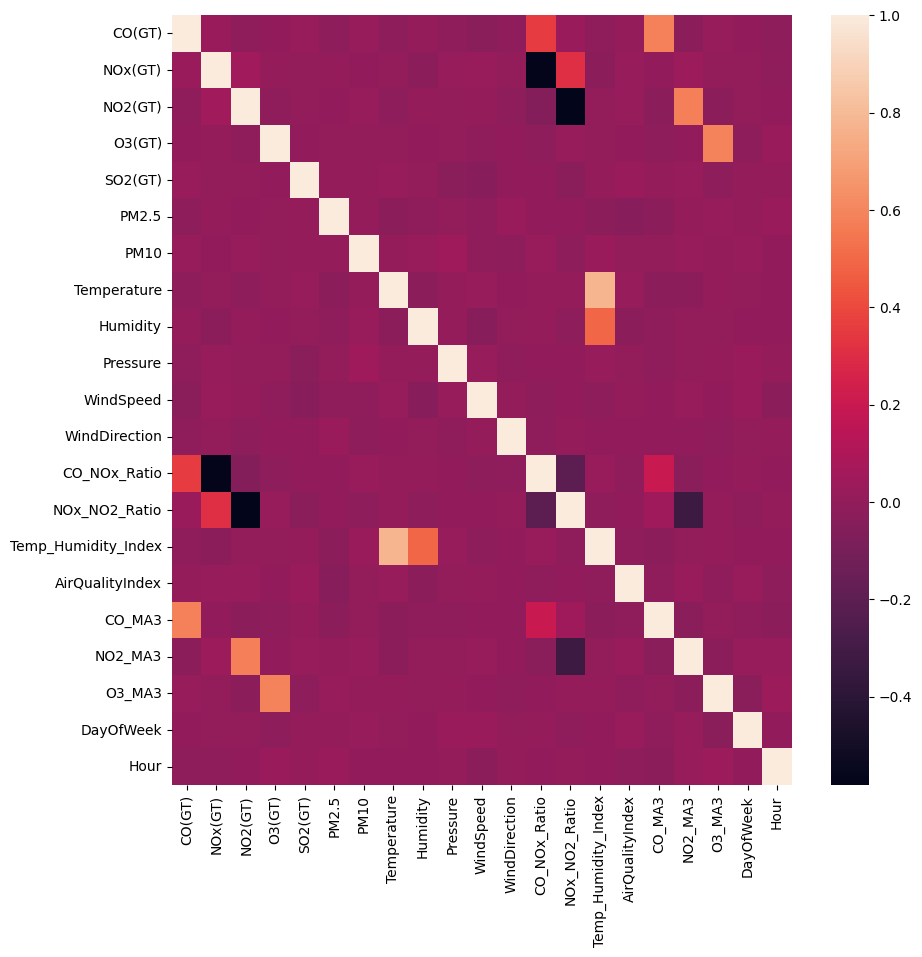

In [146]:
import seaborn as sns

# correlation
corr_matrix = df[num_col].corr()

plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix )
plt.plot()


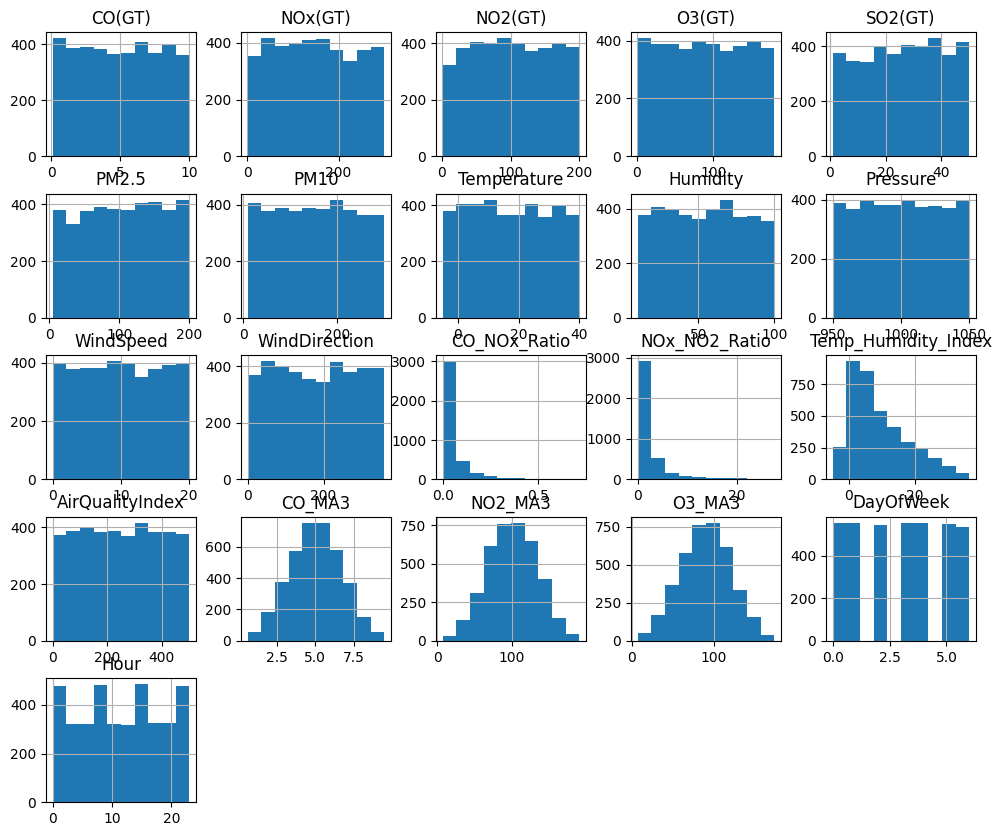

In [147]:
# histogram
df.hist(figsize=(12, 10))
plt.show()

### 3. For each column, Remove the top and bottom 10% values from the column. 

In [149]:
for col in num_col:

    lower = df[col].quantile(0.10)
    upper = df[col].quantile(0.90)

    # df = df[(df[col] >= lower) & (df[col] <= upper)]
    df[col] = df[col].clip(lower,upper)

df.head()
df.shape

(3853, 23)

### 4. Apply Min Max normalization on remaining values by subtracting each value from min value in the column and then dividing by max value.

In [150]:
for col in num_col:
    min_val = df[col].min()
    max_val = df[col].max()

    df[col] = ( df[col]- min_val)/ (max_val)



In [151]:
df.head()

,Date,Time,CO(GT),NOx(GT),NO2(GT),O3(GT),SO2(GT),PM2.5,PM10,Temperature,...,WindDirection,CO_NOx_Ratio,NOx_NO2_Ratio,Temp_Humidity_Index,AirQualityIndex,CO_MA3,NO2_MA3,O3_MA3,DayOfWeek,Hour
0,2024-01-01,00:00,0.316101,0.512945,0.666495,0.619758,0.000000,0.673590,0.636453,0.821936,...,0.532731,0.105225,0.143262,0.163724,0.648844,0.139997,0.588084,0.528477,0.0,0.000000
1,2024-01-01,01:00,0.890886,0.771611,0.630025,0.000000,0.000000,0.087866,0.401698,0.205195,...,0.870138,0.225096,0.240326,0.039782,0.343687,0.535578,0.571762,0.132299,0.0,0.000000
2,2024-01-01,02:00,0.711260,0.721447,0.000000,0.163375,0.397505,0.261953,0.000000,0.704997,...,0.731878,0.175295,0.937717,0.332717,0.196506,0.567327,0.290490,0.074883,0.0,0.000000
3,2024-01-01,03:00,0.563860,0.049662,0.864568,0.751998,0.000000,0.601951,0.860954,0.762429,...,0.847750,0.828064,0.000000,0.962870,0.569980,0.611836,0.384077,0.129785,0.0,0.047619
4,2024-01-01,04:00,0.074529,0.044509,0.498661,0.480597,0.865193,0.407394,0.860954,0.311061,...,0.000000,0.197857,0.006537,0.431794,0.708467,0.306169,0.329115,0.336129,0.0,0.095238


### 5. Categorize the data into 10 bins of equal frequency.

In [152]:

for col in num_col:
    col_name = col+'_bin'
    df[col + "_bin"] = pd.qcut(df[col], 10, labels=False, duplicates="drop")

In [153]:
df.shape

(3853, 44)

In [154]:
df.head()

,Date,Time,CO(GT),NOx(GT),NO2(GT),O3(GT),SO2(GT),PM2.5,PM10,Temperature,...,WindDirection_bin,CO_NOx_Ratio_bin,NOx_NO2_Ratio_bin,Temp_Humidity_Index_bin,AirQualityIndex_bin,CO_MA3_bin,NO2_MA3_bin,O3_MA3_bin,DayOfWeek_bin,Hour_bin
0,2024-01-01,00:00,0.316101,0.512945,0.666495,0.619758,0.000000,0.673590,0.636453,0.821936,...,5,3,4,3,6,2,9,8,0,0
1,2024-01-01,01:00,0.890886,0.771611,0.630025,0.000000,0.000000,0.087866,0.401698,0.205195,...,8,5,5,1,4,8,8,2,0,0
2,2024-01-01,02:00,0.711260,0.721447,0.000000,0.163375,0.397505,0.261953,0.000000,0.704997,...,7,4,9,5,2,8,4,1,0,0
3,2024-01-01,03:00,0.563860,0.049662,0.864568,0.751998,0.000000,0.601951,0.860954,0.762429,...,8,8,0,8,6,9,6,2,0,0
4,2024-01-01,04:00,0.074529,0.044509,0.498661,0.480597,0.865193,0.407394,0.860954,0.311061,...,0,5,1,6,7,4,5,5,0,0


In [155]:
for col in num_col:
    sort_index = df[col].sort_values().index

    n = len(df)
    bins_size = n // 10
    

### 6. Fit the model for Air Quality Index using SVM and do Grid Search Analysis.

In [156]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'NOx(GT)', 'NO2(GT)', 'O3(GT)', 'SO2(GT)',
       'PM2.5', 'PM10', 'Temperature', 'Humidity', 'Pressure', 'WindSpeed',
       'WindDirection', 'CO_NOx_Ratio', 'NOx_NO2_Ratio', 'Temp_Humidity_Index',
       'AirQualityIndex', 'CO_MA3', 'NO2_MA3', 'O3_MA3', 'DayOfWeek', 'Hour',
       'CO(GT)_bin', 'NOx(GT)_bin', 'NO2(GT)_bin', 'O3(GT)_bin', 'SO2(GT)_bin',
       'PM2.5_bin', 'PM10_bin', 'Temperature_bin', 'Humidity_bin',
       'Pressure_bin', 'WindSpeed_bin', 'WindDirection_bin',
       'CO_NOx_Ratio_bin', 'NOx_NO2_Ratio_bin', 'Temp_Humidity_Index_bin',
       'AirQualityIndex_bin', 'CO_MA3_bin', 'NO2_MA3_bin', 'O3_MA3_bin',
       'DayOfWeek_bin', 'Hour_bin'],
      dtype='object')

In [157]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR

X = df.drop(["AirQualityIndex",'Date','Time'], axis= 1)
y = df["AirQualityIndex"]


X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8, random_state= 42)



In [158]:
X.columns

Index(['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'O3(GT)', 'SO2(GT)', 'PM2.5', 'PM10',
       'Temperature', 'Humidity', 'Pressure', 'WindSpeed', 'WindDirection',
       'CO_NOx_Ratio', 'NOx_NO2_Ratio', 'Temp_Humidity_Index', 'CO_MA3',
       'NO2_MA3', 'O3_MA3', 'DayOfWeek', 'Hour', 'CO(GT)_bin', 'NOx(GT)_bin',
       'NO2(GT)_bin', 'O3(GT)_bin', 'SO2(GT)_bin', 'PM2.5_bin', 'PM10_bin',
       'Temperature_bin', 'Humidity_bin', 'Pressure_bin', 'WindSpeed_bin',
       'WindDirection_bin', 'CO_NOx_Ratio_bin', 'NOx_NO2_Ratio_bin',
       'Temp_Humidity_Index_bin', 'AirQualityIndex_bin', 'CO_MA3_bin',
       'NO2_MA3_bin', 'O3_MA3_bin', 'DayOfWeek_bin', 'Hour_bin'],
      dtype='object')

In [159]:
svm = SVR() 
svm.fit(X_train, y_train)

SVR()

In [160]:

param_grid = {
    'C': [1, 10, 100], # regularization parameter - controls how strict the model is 
    'gamma': ['scale', 0.1, 0.01,0.001], # influence the range of points 
    'kernel': ['rbf', 'linear','poly'] # it will decide the shape - linear, rbf(radial basis function) - curved, poly
}
# guess all the possible combination there can be - select the best one
grid = GridSearchCV(svm, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [1, 10, 100],
                         'gamma': ['scale', 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'linear', 'poly']},
             scoring='r2')

In [161]:
print(grid.best_params_)

{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


In [162]:
best_model = grid.best_estimator_
best_model

SVR(C=1, kernel='linear')

In [163]:
y_pred = best_model.predict(X_test)


In [164]:
X.shape

(3853, 41)

In [165]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.9819316433261158
MSE: 0.001692929757506109


### 7. Calculate Bias, Variance and display full classification report

In [168]:
from sklearn.metrics import mean_squared_error

# Predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)


In [167]:

bias = mean_squared_error(y_train, y_train_pred)
variance = abs(mean_squared_error(y_test, y_test_pred) - bias)

print("Bias:", bias)
print("Variance:", variance)

Bias: 0.001627726266095041
Variance: 6.520349141106788e-05
